# Sequential Monte Carlo: available kernels and controls

This notebook demonstrates fixed and adaptive schedules, particle batching, waste-free
updates, persistent SMC, MCMC tuning and pretuning, partial posteriors, and diagnostics.
We begin with a Gaussian model whose posterior **and evidence** are known, then revisit
the funnel, multimodal mixture, and spiral targets.

The kernels reuse BlackJAX implementations through probjax adapters. All inference runs
are compiled. Particle counts and iteration caps are explicit so the notebook runs on a
CPU; increase them when exploring more difficult targets. For filtering, SMC², trajectory
sampling, and real-time observations, see [temporal_smc.ipynb](temporal_smc.ipynb).

In [1]:
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax.scipy.stats import norm, multivariate_normal
from probjax.inference import (
    SMC, hmc, smc, adaptive_smc_kernel, persistent_smc_kernel,
    waste_free_smc, tuned_smc, pretuned_smc, PartialPosteriorsPath,
    population_diagnostics, summarize_replicates,
)

key = jax.random.key(42)
def next_key():
    global key
    key, result = jax.random.split(key)
    return result

num_particles = 2048
batch_size = 128
particles = jax.random.normal(next_key(), (num_particles, 2))
observation = jnp.array([1.5, -0.75])
noise_cov = jnp.array([[0.4, 0.15], [0.15, 0.7]])
logprior = lambda x: norm.logpdf(x).sum()
loglikelihood = lambda x: multivariate_normal.logpdf(observation, x, noise_cov)
posterior_cov = jnp.linalg.inv(jnp.eye(2) + jnp.linalg.inv(noise_cov))
posterior_mean = posterior_cov @ jnp.linalg.solve(noise_cov, observation)
exact_log_evidence = multivariate_normal.logpdf(observation, jnp.zeros(2), jnp.eye(2)+noise_cov)
params = {'step_size': jnp.array([0.2]), 'inverse_mass_matrix': jnp.ones((1, 2))}
schedule = jnp.linspace(0., 1., 25)[1:]
print('Exact posterior mean:', posterior_mean)
print('Exact log evidence:', float(exact_log_evidence))

Exact posterior mean: [ 1.1293744 -0.5408271]
Exact log evidence: -3.316518545150757


## Fixed schedules, adaptive stopping, waste-free and persistent SMC

Adaptive kernels select temperatures using an ESS target; `run_adaptive` stops at one
and reports whether it completed before its cap. Waste-free SMC retains intermediate
MCMC states: `p=4` means 512 resampled seeds supply 2048 retained states. Those states
are correlated. Persistent SMC reuses populations from preceding temperatures and
allocates storage for the declared schedule.

`batch_size=128` reduces peak population-mapping memory. It controls execution batching,
not the number of observations or particles in the statistical algorithm.

Fixed       : stages=24, logZ=-3.130, mean=[ 1.1607983 -0.5458863]
Adaptive    : stages= 6, logZ=-3.343, mean=[ 1.10833    -0.54687995]
Waste-free  : stages= 6, logZ=-3.382, mean=[ 1.132436 -0.548406]
Persistent  : stages=24, logZ=-3.299, mean=[ 1.1275777 -0.5405443]


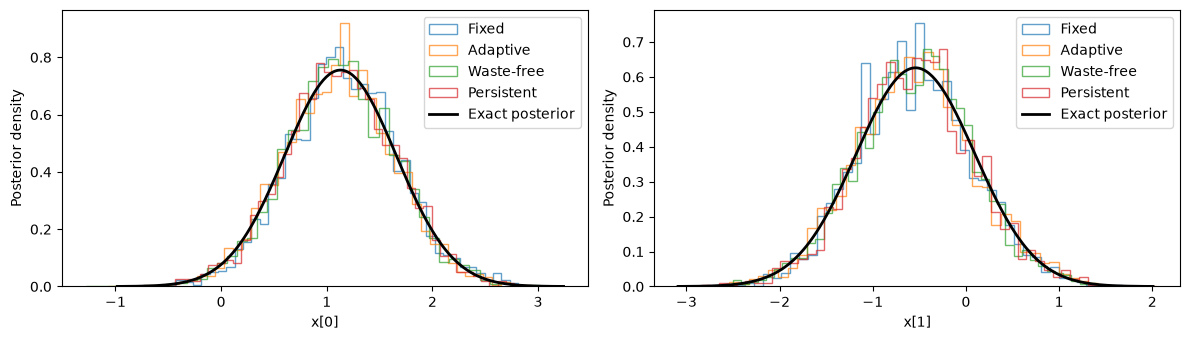

In [2]:
fixed = smc(logprior_fn=logprior, loglikelihood_fn=loglikelihood,
            mcmc_kernel=hmc, num_mcmc_steps=3, num_integration_steps=4,
            batch_size=batch_size)
adaptive = adaptive_smc_kernel(logprior_fn=logprior, loglikelihood_fn=loglikelihood,
            mcmc_kernel=hmc, num_mcmc_steps=3, num_integration_steps=4,
            target_ess=0.85, batch_size=batch_size)
waste_free = waste_free_smc(logprior, loglikelihood, num_particles=num_particles, p=4,
            adaptive=True, mcmc_kernel=hmc, num_integration_steps=4,
            target_ess=0.85, batch_size=batch_size)
persistent = persistent_smc_kernel(logprior_fn=logprior, loglikelihood_fn=loglikelihood,
            mcmc_kernel=hmc, num_mcmc_steps=3, num_integration_steps=4,
            batch_size=batch_size)

results = {}
results['Fixed'] = SMC(fixed).run(next_key(), fixed.init(particles), schedule, params)
results['Adaptive'] = SMC(adaptive).run_adaptive(next_key(), adaptive.init(particles), params, max_steps=80)
results['Waste-free'] = SMC(waste_free).run_adaptive(next_key(), waste_free.init(particles), params, max_steps=80)
results['Persistent'] = SMC(persistent).run(next_key(), persistent.init(particles, n_schedule=len(schedule)), schedule, params)
assert all(bool(result.completed) for result in results.values())

def population(result):
    state = getattr(result.state, 'sampler_state', result.state)
    weights = state.weights if hasattr(state, 'weights') else jnp.full(state.particles.shape[0], 1/state.particles.shape[0])
    return state.particles, weights

for name, result in results.items():
    values, weights = population(result)
    mean = jnp.sum(weights[:, None]*values, axis=0)
    print(f'{name:12s}: stages={int(result.num_steps):2d}, logZ={float(result.log_evidence):.3f}, mean={np.asarray(mean)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for dimension, ax in enumerate(axes):
    x = jnp.linspace(posterior_mean[dimension]-4*jnp.sqrt(posterior_cov[dimension, dimension]),
                     posterior_mean[dimension]+4*jnp.sqrt(posterior_cov[dimension, dimension]), 300)
    for name, result in results.items():
        values, weights = population(result)
        ax.hist(np.asarray(values[:, dimension]), weights=np.asarray(weights), bins=45,
                density=True, histtype='step', label=name, alpha=0.7)
    ax.plot(x, norm.pdf(x, posterior_mean[dimension], jnp.sqrt(posterior_cov[dimension, dimension])),
            'k', linewidth=2, label='Exact posterior')
    ax.set(xlabel=f'x[{dimension}]', ylabel='Posterior density')
    ax.legend()
plt.tight_layout(); plt.show()

## Compile time, warm execution, and retained histories

Compilation is timed separately from warm execution. Comparisons between methods must
also account for their different numbers of targets and MCMC moves. `run` keeps evidence
and final diagnostics without a population trace. `sample` additionally retains all
populations and can use substantially more memory.

Compile: 0.675s; warm run: 183.39ms


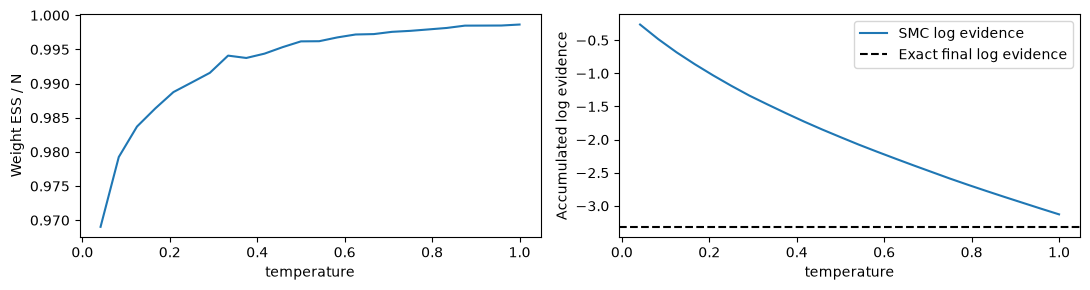

One-stage adaptive run completed: False


In [3]:
initial = fixed.init(particles)
run_key = next_key()
compiled = jax.jit(lambda k, s: SMC.run_kernel(k, fixed, s, schedule, params))
start = time.perf_counter()
executable = compiled.lower(run_key, initial).compile()
compile_seconds = time.perf_counter()-start
executable(run_key, initial).log_evidence.block_until_ready()
start = time.perf_counter()
for _ in range(5):
    executable(run_key, initial).log_evidence.block_until_ready()
print(f'Compile: {compile_seconds:.3f}s; warm run: {(time.perf_counter()-start)/5*1000:.2f}ms')

history = SMC(fixed).sample(run_key, initial, schedule, params)
states, infos = history.info
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(schedule, 1/jnp.sum(states.weights**2, axis=1)/num_particles)
axes[0].set(xlabel='temperature', ylabel='Weight ESS / N')
axes[1].plot(schedule, jnp.cumsum(infos.log_likelihood_increment), label='SMC log evidence')
axes[1].axhline(float(exact_log_evidence), color='black', linestyle='--', label='Exact final log evidence')
axes[1].set(xlabel='temperature', ylabel='Accumulated log evidence'); axes[1].legend()
plt.tight_layout(); plt.show()

capped = SMC(adaptive).run_adaptive(next_key(), adaptive.init(particles), params, max_steps=1)
print('One-stage adaptive run completed:', bool(capped.completed))
resumed = SMC(adaptive).run_adaptive(capped.key, capped.state, capped.params,
                                    initial_log_evidence=capped.log_evidence)
assert bool(resumed.completed)

## Tuning after a stage and pretuning before a stage

`tuned_smc` delegates to BlackJAX's inner-kernel tuning wrapper. This example updates
HMC geometry from the population, leaving its step size fixed. A custom callback can
also use move diagnostics. Initial parameters are unbatched; returned callback values
have a leading shared or per-particle axis, whose shape must stay fixed under JIT.

`pretuned_smc` uses BlackJAX pilot moves to evolve a distribution of step sizes. Its
initial parameters already have explicit batch axes. Pilot and production moves use
independent random keys. The default movement diagnostic uses a full shared mass matrix.
Pilot work has a cost and currently maps its population together, even when production
moves use batching.

Tuned geometry: [[0.33644897 0.05787178]
 [0.05787178 0.46739492]]


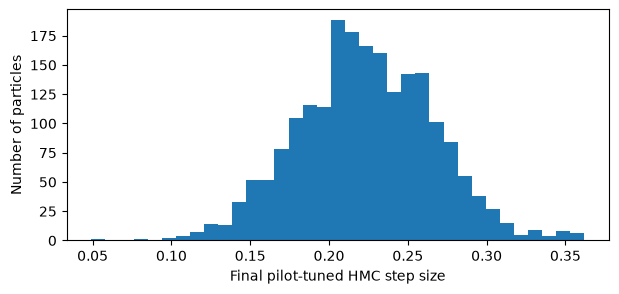

Tuned / pretuned / exact log evidence: -3.3189172744750977 -3.303307056427002 -3.316518545150757


In [4]:
def update_geometry(key, state, info):
    covariance = jnp.cov(state.particles.T) + 1e-3*jnp.eye(2)
    return {'step_size': jnp.array([0.2]), 'inverse_mass_matrix': covariance[None]}

tuned = tuned_smc(logprior, loglikelihood, mcmc_kernel=hmc,
                  mcmc_parameters={'step_size': 0.2, 'inverse_mass_matrix': jnp.eye(2)},
                  parameter_update_fn=update_geometry, num_mcmc_steps=3,
                  num_integration_steps=4, batch_size=batch_size)
tuned_result = SMC(tuned).run_adaptive(next_key(), tuned.init(particles), {})
assert bool(tuned_result.completed)
print('Tuned geometry:', tuned_result.params['inverse_mass_matrix'][0])

pilot_params = {'step_size': jnp.full((num_particles,), 0.2),
                'inverse_mass_matrix': jnp.eye(2)[None]}
pretuned = pretuned_smc(logprior, loglikelihood, mcmc_kernel=hmc,
                        mcmc_parameters=pilot_params, num_particles=num_particles,
                        sigma_parameters={'step_size': 0.02}, positive_parameters=['step_size'],
                        num_mcmc_steps=3, num_integration_steps=4, batch_size=batch_size)
pretuned_result = SMC(pretuned).run_adaptive(next_key(), pretuned.init(particles), {})
assert bool(pretuned_result.completed)
plt.figure(figsize=(7, 3))
plt.hist(np.asarray(pretuned_result.params['step_size']), bins=35)
plt.xlabel('Final pilot-tuned HMC step size'); plt.ylabel('Number of particles'); plt.show()
print('Tuned / pretuned / exact log evidence:', float(tuned_result.log_evidence),
      float(pretuned_result.log_evidence), float(exact_log_evidence))

## Partial posteriors: assimilating data in a fixed parameter space

`PartialPosteriorsPath` changes which observations enter the parameter posterior.
This differs from latent-path filtering: there is no evolving latent state in this
example. The same SMC machinery and MCMC adapter handle either a scalar temperature
or a vector of observation inclusion weights.

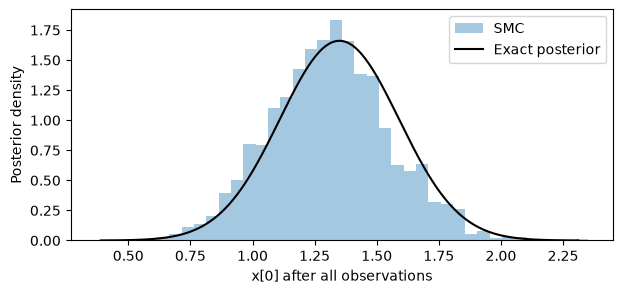

In [5]:
data = jnp.array([1., -0.5]) + 0.7*jax.random.normal(next_key(), (8, 2))
def partial_posterior(mask):
    return lambda x: logprior(x) + jnp.sum(mask[:, None]*norm.logpdf(data, x, 0.7))
partial_kernel = smc(path=PartialPosteriorsPath(), partial_logposterior_factory=partial_posterior,
                     logprior_fn=logprior, mcmc_kernel=hmc, num_mcmc_steps=3,
                     num_integration_steps=4, batch_size=batch_size)
mask_schedule = jnp.arange(8)[None, :] < jnp.arange(1, 9)[:, None]
partial_result = SMC(partial_kernel).run(next_key(), partial_kernel.init(particles, num_datapoints=8),
                                        mask_schedule.astype(float), params)
partial_variance = 1/(1+len(data)/0.7**2)
partial_mean = partial_variance*data.sum(0)/0.7**2
values, weights = population(partial_result)
plt.figure(figsize=(7, 3))
plt.hist(np.asarray(values[:, 0]), weights=np.asarray(weights), bins=40, density=True, alpha=0.4, label='SMC')
x = jnp.linspace(partial_mean[0]-4*jnp.sqrt(partial_variance), partial_mean[0]+4*jnp.sqrt(partial_variance), 250)
plt.plot(x, norm.pdf(x, partial_mean[0], jnp.sqrt(partial_variance)), 'k', label='Exact posterior')
plt.xlabel('x[0] after all observations'); plt.ylabel('Posterior density'); plt.legend(); plt.show()

## Accuracy and diversity diagnostics

Weight ESS can be high even when many particles are duplicates. Ancestry labels expose
resampling collapse, while independent repetitions quantify Monte Carlo variability.
The standard error below is computed across independent **run estimates**, not by
pretending particles within one SMC run are independent. Evidence is averaged on its
original scale; mean log evidence is a different quantity.

In [6]:
values, weights = population(results['Fixed'])
d = population_diagnostics(values, jnp.log(weights), results['Fixed'].final_info.ancestors)
print('Final weight ESS / distinct particles / last-stage parents:',
      float(d.ess), int(d.unique_particles), int(d.unique_ancestors))

def independent_run(key):
    initial_key, run_key = jax.random.split(key)
    state = fixed.init(jax.random.normal(initial_key, (512, 2)))
    result = SMC.run_kernel(run_key, fixed, state, schedule, params)
    return jnp.exp(result.log_evidence), jnp.sum(result.state.weights*result.state.particles[:, 0])

evidence_estimates, mean_estimates = jax.jit(jax.vmap(independent_run))(jax.random.split(next_key(), 8))
evidence_stats = summarize_replicates(evidence_estimates)
mean_stats = summarize_replicates(mean_estimates)
print('Evidence mean +/- MC standard error:', float(evidence_stats.mean), float(evidence_stats.standard_error),
      '; exact:', float(jnp.exp(exact_log_evidence)))
print('Posterior mean x[0] +/- MC standard error:', float(mean_stats.mean), float(mean_stats.standard_error),
      '; exact:', float(posterior_mean[0]))

Final weight ESS / distinct particles / last-stage parents: 2045.390380859375 2048 2018
Evidence mean +/- MC standard error: 0.044322557747364044 0.00044933619210496545 ; exact: 0.03627891466021538
Posterior mean x[0] +/- MC standard error: 1.137832522392273 0.0068730455823242664 ; exact: 1.129374384880066


## Challenging target gallery

These examples retain the funnel, five-mode mixture, and curved spiral from the original
notebook. We use a broad Gaussian starting distribution and temper `log_target-log_prior`.
The modest default compute budget is illustrative: verify mode coverage and repeat runs
before drawing conclusions. More particles alone do not repair a poorly mixing move.
Black contours show target-density levels; the plotted window may omit tail mass.

In [7]:
# --- Neal's funnel ---
def funnel_logdensity(z):
    x, v = z[0], z[1]
    return jax.scipy.stats.norm.logpdf(v, 0.0, 3.0) + \
           jax.scipy.stats.norm.logpdf(x, 0.0, jnp.exp(v / 2.0))


# --- Gaussian mixture ---
mixture_means = jnp.array([
    [10.0, 0.0], [0.0, 10.0], [-10.0, 0.0], [0.0, -10.0], [0.0, 0.0],
])
mixture_std = 0.7

def mixture_logdensity(z):
    logps = jax.vmap(
        lambda mu: jax.scipy.stats.norm.logpdf(z, mu, mixture_std).sum()
    )(mixture_means)
    return jax.scipy.special.logsumexp(logps) - jnp.log(len(mixture_means))


# --- Spiral ---
# A thin three-turn Archimedean spiral approximated by a Gaussian mixture.
key = jax.random.PRNGKey(7)
t_spiral = jnp.linspace(0.0, 6 * jnp.pi, 150)
spiral_scale = 0.15
spiral_std = 0.15
spiral_means = spiral_scale * jnp.stack(
    [t_spiral * jnp.cos(t_spiral), t_spiral * jnp.sin(t_spiral)], axis=-1
)

def spiral_logdensity(z):
    logps = jax.vmap(
        lambda mu: jax.scipy.stats.norm.logpdf(z, mu, spiral_std).sum()
    )(spiral_means)
    return jax.scipy.special.logsumexp(logps) - jnp.log(len(spiral_means))

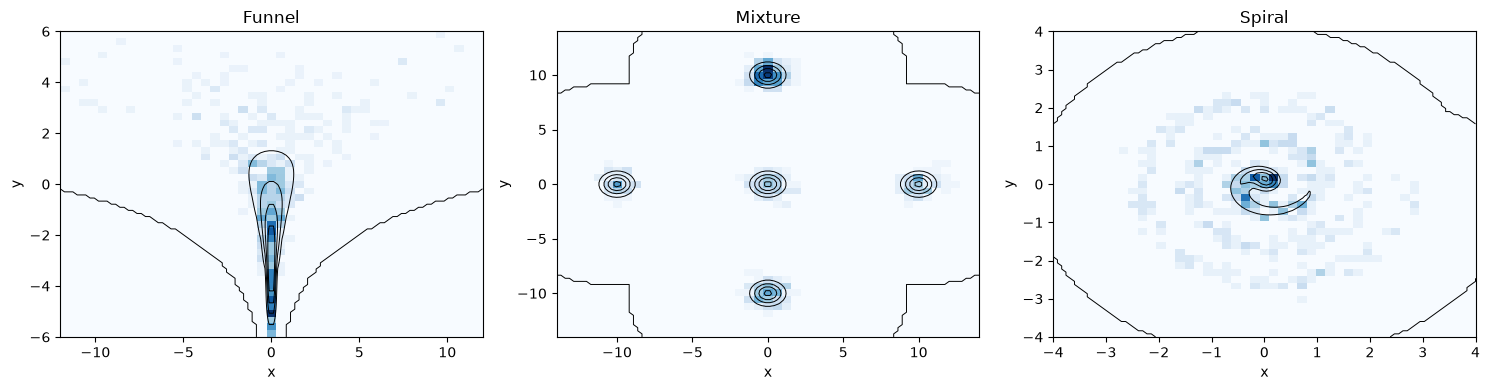

In [8]:
gallery_prior_sd = 5.
gallery_prior = lambda x: norm.logpdf(x, 0., gallery_prior_sd).sum()
gallery_targets = [('Funnel', funnel_logdensity, ((-12, 12), (-6, 6))),
                   ('Mixture', mixture_logdensity, ((-14, 14), (-14, 14))),
                   ('Spiral', spiral_logdensity, ((-4, 4), (-4, 4)))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, target, limits) in zip(axes, gallery_targets):
    kernel = smc(logprior_fn=gallery_prior, loglikelihood_fn=lambda x, target=target: target(x)-gallery_prior(x),
                 mcmc_kernel=hmc, num_mcmc_steps=2, num_integration_steps=4, batch_size=128)
    initial = kernel.init(gallery_prior_sd*jax.random.normal(next_key(), (512, 2)))
    result = SMC(kernel).run(next_key(), initial, jnp.linspace(0., 1., 41)[1:],
                             {'step_size': jnp.array([0.05]), 'inverse_mass_matrix': jnp.ones((1, 2))})
    pts, weights = population(result)
    ax.hist2d(np.asarray(pts[:, 0]), np.asarray(pts[:, 1]), weights=np.asarray(weights),
              bins=45, range=limits, density=True, cmap='Blues')
    gx = jnp.linspace(*limits[0], 100); gy = jnp.linspace(*limits[1], 100)
    xx, yy = jnp.meshgrid(gx, gy)
    density = jnp.exp(jax.vmap(target)(jnp.stack((xx.ravel(), yy.ravel()), axis=-1))).reshape(xx.shape)
    ax.contour(xx, yy, density, levels=5, colors='black', linewidths=0.7)
    ax.set(title=name, xlabel='x', ylabel='y')
plt.tight_layout(); plt.show()

## Choosing the next control

- Use adaptive temperatures when a fixed schedule needs excessive manual tuning.
- Use batching to lower peak memory; it need not reduce wall time.
- Compare waste-free retention with longer independent moves using effective accuracy per cost.
- Use geometry tuning or pilot pretuning when move efficiency varies across the path.
- Inspect evidence, diversity, and independent runs alongside posterior plots.
- For physical-time inference, see the temporal notebook: it adds Kalman/particle backends,
  SMC², observation tempering, adaptive proposals and move budgets, trajectory sampling,
  persistent streaming windows, and inner-particle capacity adaptation.

[SMC guide](../../docs/guides/smc.md) · [Temporal guide](../../docs/guides/temporal-smc.md)